<h2>Predviđanje nivoa zavisnosti od mobilnih telefona - 3. EDA - anketa</h2>
<small>Strahinja Đukić E2 89/2025, Nikolina Rogan E2 96/2025</small>
<h3>Uvod</h3>

Nakon primarne analize sintetičkog skupa podataka, uočena su ograničenja u pogledu nebalansiranosti podataka i izostanka nekih od ključnih korelacija. Kako bismo osigurali validnost kasnijih zaključaka i stekli bolji uvid u stvarne obrasce ponašanja, sproveli smo [anketu](https://forms.gle/E6cy5ovyuEbUV7hQ9) gdje smo dobili novih 100 unosa. U nastavku ćemo se fokusirati na eksplorativnu analizu ovih podataka kako bismo identifikovali korelacije i trendove koji su u sintetičkom datasetu ostali skriveni.

<h3>Podaci</h3>

Ispitanicima smo u okviru ankete postavili 17 pitanja, koja smo formulisali na osnovu postojećih kolona u inicijalnom skupu podataka.

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("src"))

df = pd.read_csv("data/podaci_ankete.csv")
df.head()

,Timestamp,Gender,Age,Daily_Usage_Hours,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Phone_Usage_Purpose,Screen_Time_Before_Bed,Weekend_Usage_Hours,Sleep_Hours,Anxiety_Level,Social_Interactions,Family_Communication,Exercise_Hours,Academic_Performance,Addiction_Level
0,3/18/2026 12:08:45,Female,25,4.0,20,3,1.0,1.0,Other,1.0,3.0,7.0,2,5,8,1.0,85,3
1,3/18/2026 12:00:48,Female,22,10.0,30,3,2.0,1.0,Social Media,2.0,4.0,6.0,1,6,8,1.0,55,6
2,3/19/2026 10:16:55,Female,26,3.0,35,3,2.0,0.0,Social Media,1.0,5.0,8.0,7,4,9,1.0,95,6
3,3/20/2026 12:04:01,Male,26,2.0,40,2,2.0,0.0,Social Media,0.0,3.0,10.0,3,5,7,1.0,85,4
4,3/17/2026 19:45:30,Female,25,3.0,86,3,2.0,0.0,Social Media,1.0,4.0,6.0,8,8,8,1.0,85,7


<h2> Vizuelizacija podataka</h2>

U nastavku ćemo prikazati vizuelnu reprezentaciju podataka i povući paralele sa sintetičkim podacima.

<h3> Analiza ciljnog atributa</h3>

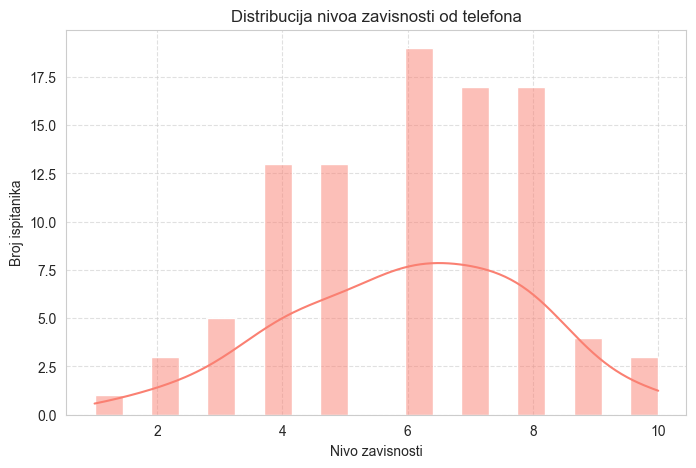

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['Addiction_Level'], bins=20, kde=True, color='salmon')

plt.title('Distribucija nivoa zavisnosti od telefona')
plt.xlabel('Nivo zavisnosti')
plt.ylabel('Broj ispitanika')

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Uočavamo da su ispitanici u anketi dali balansiranije i realnije odgovore u poređenju sa sintetičkim setom. Većina ispitanika se nalazi u opsegu 6-8 što govori o visokom nivou svijesti o problemu zavisnosti, ali nemamo forsiranje maksimalne vrijednosti kao što je bio slučaj sa prvim skupom podataka.

<h3> Sociološki faktori i navike </h3>

U nastavku ćemo analizirati uticaj socioloških faktora i svakodnevnih navika na posmatrani problem. Očekujemo veću povezanost između prirodno međusobno zavisnih faktora, što je u sintetičkom skupu izostavljeno.

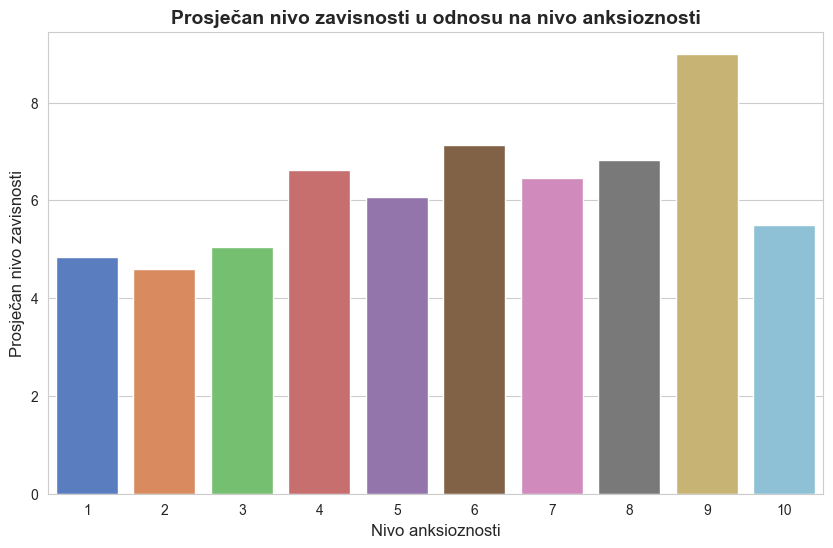

In [18]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

sns.barplot(data=df, 
            x='Anxiety_Level', 
            y='Addiction_Level', 
            palette='muted', 
            hue='Anxiety_Level', 
            legend=False, 
            errorbar=None)

plt.title('Prosječan nivo zavisnosti u odnosu na nivo anksioznosti', fontsize=14, fontweight='bold')
plt.xlabel('Nivo anksioznosti', fontsize=12)
plt.ylabel('Prosječan nivo zavisnosti', fontsize=12)

plt.show()

Na osnovu grafika vidimo da sada nivo zavisnosti stvarno varira i mijenja se, to na sintetičkim podacima nije bio slučaj, gdje smo za sve nivoe depresije dobijali skoro identičan nivo zavisnosti. Dakle, primjećujemo stvarne razlike među ispitanicima koje su ranije bile "nevidljive". Primetan je i porast nivoa anksioznosti pri višim nivoima zavisnosti od telefona.

C:\Users\Strahinja\AppData\Local\Temp\ipykernel_12228\3148912697.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Text(0.5, 0, 'Dnevno vrijeme korišćenja telefona')

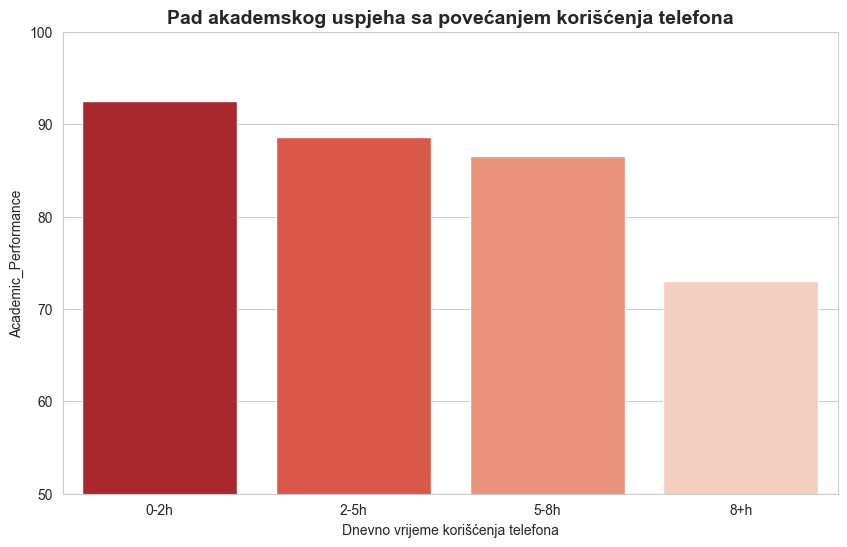

In [19]:
df['Usage_Group'] = pd.cut(
    df['Daily_Usage_Hours'],
    bins=[0, 2, 5, 8, 24],
    labels=['0-2h', '2-5h', '5-8h', '8+h'],
    include_lowest=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='Usage_Group',
    y='Academic_Performance',
    palette='Reds_r',
    errorbar=None
)

plt.ylim(50, 100)
plt.title('Pad akademskog uspjeha sa povećanjem korišćenja telefona', fontsize=14, fontweight='bold')
plt.xlabel('Dnevno vrijeme korišćenja telefona')

Za razliku od sintetičkog seta koji nije prepoznavao vezu između korišćenja telefona i učenja, realni podaci pokazuju jasan opadajući trend. Ovaj pad potvrđuje činjenicu da digitalna zavisnost direktno ugrožava akademska postignuća.

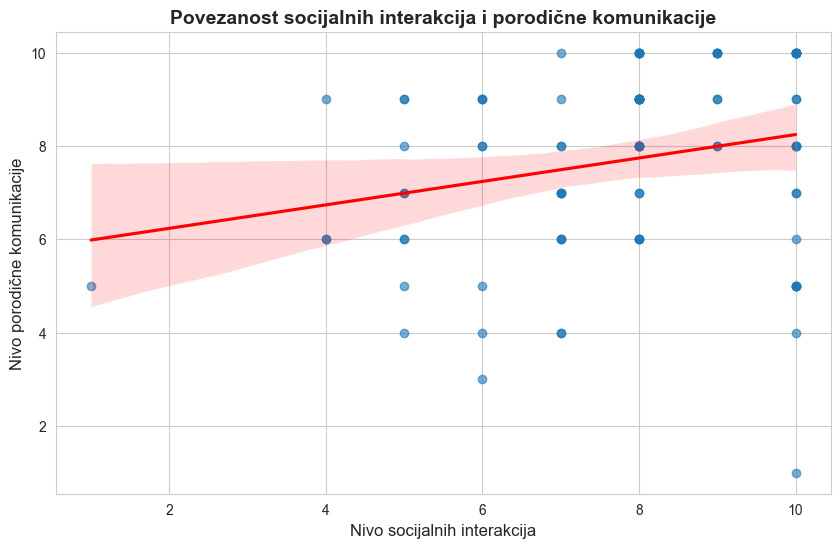

In [20]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.regplot(data=df,
            x='Social_Interactions',
            y='Family_Communication',
            scatter_kws={'alpha': 0.6},
            line_kws={'color': 'red'})

plt.title('Povezanost socijalnih interakcija i porodične komunikacije', fontsize=14, fontweight='bold')
plt.xlabel('Nivo socijalnih interakcija', fontsize=12)
plt.ylabel('Nivo porodične komunikacije', fontsize=12)

plt.show()

Grafik pokazuje da ispitanici sa razvijenijim društvenim životom uglavnom održavaju i kvalitetniju komunikaciju unutar porodice. Ovim potvrđujemo validnost anketnog uzorka jer su stvarni podaci, za razliku od sintetičkih, uspjeli da prikažu prirodnu i logičnu međuzavisnost ovih fakora.

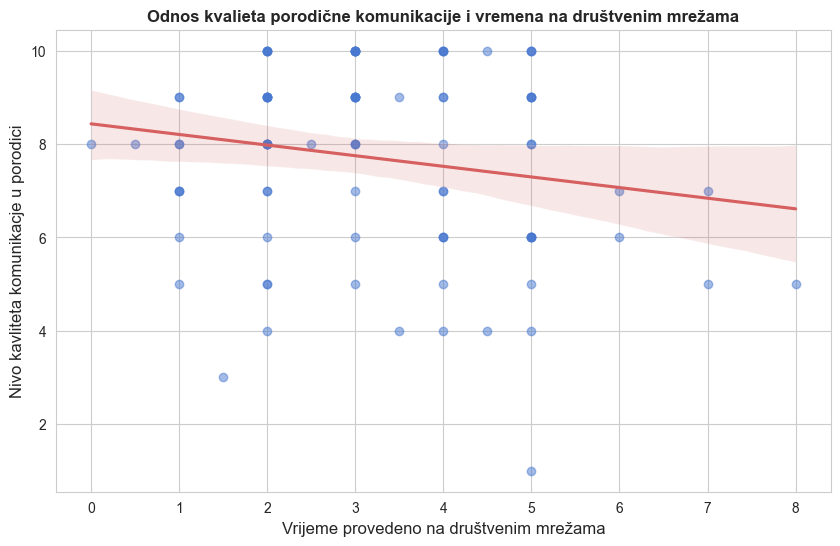

In [21]:
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x='Time_on_Social_Media', y='Family_Communication', 
            scatter_kws={'alpha':0.5, 'color':'#4878d0'}, 
            line_kws={'color':'#d65f5f'})

plt.title('Odnos kvalieta porodične komunikacije i vremena na društvenim mrežama', fontsize=12, fontweight='bold')
plt.xlabel('Vrijeme provedeno na društvenim mrežama', fontsize=12)
plt.ylabel('Nivo kavliteta komunikacje u porodici', fontsize=12)

plt.show()

Grafik pokazuje jasnu negativnu korelaciju između vremena na društvenim mrežama i kvaliteta komunikacije u porodici. Za razliku od sintetičkog seta gdje je ova veza izostala, realni podaci potvrđuju da prekomjerna upotreba mreža narušava kvalitet porodičnih odnosa, pri čemu najaktivniji korisnici daju najlošije ocjene porodičnoj komunikaciji.

<h3> Demografski faktori </h3>

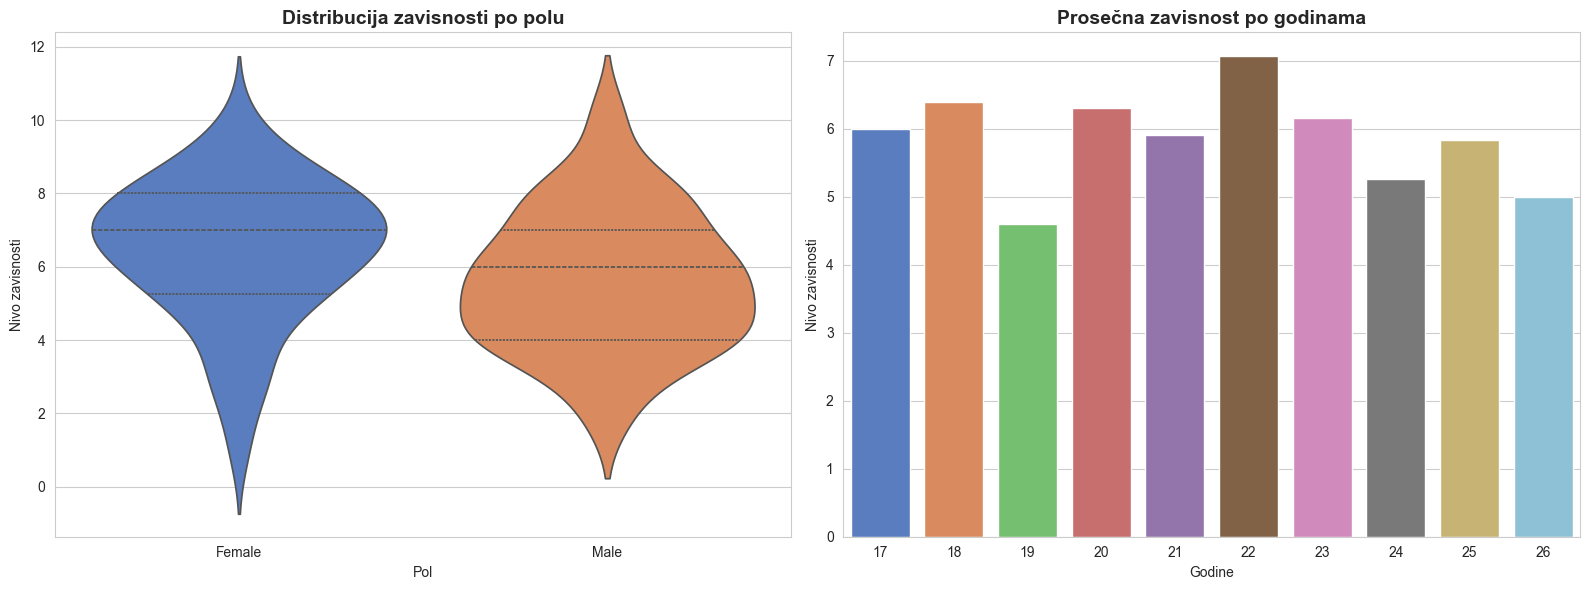

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df, x='Gender', y='Addiction_Level', ax=axes[0], palette='muted', hue='Gender', legend=False, inner="quartile")
axes[0].set_title('Distribucija zavisnosti po polu', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pol')
axes[0].set_ylabel('Nivo zavisnosti')

sns.barplot(data=df, x='Age', y='Addiction_Level', ax=axes[1], palette='muted', hue='Age', legend=False, errorbar=None)
axes[1].set_title('Prosečna zavisnost po godinama', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Godine')
axes[1].set_ylabel('Nivo zavisnosti')

plt.tight_layout()
plt.show()

Dok sintetički podaci pokazuju jaku uniformnost gdje su nivoi zavisnosti identični za sve polove i godine, podaci iz ankete otkrivaju varijabilnost i prirodni 'šum' karakterističan za ljudsko ponašanje. Na realnim podacima vidimo jasne razlike po godinama i širu distribuciju zavisnosti unutar polova (nivoi 4–8), što potvrđuje da naš uzorak vjerno oslikava kompleksnost problema koju vještački generisani podaci nisu uspjeli da simuliraju.

<h3> Navike korišćenja telefona </h3>

U nastavku će fokus biti na anlizi svakodnevnih navika upotrebe mobilnih telefona.

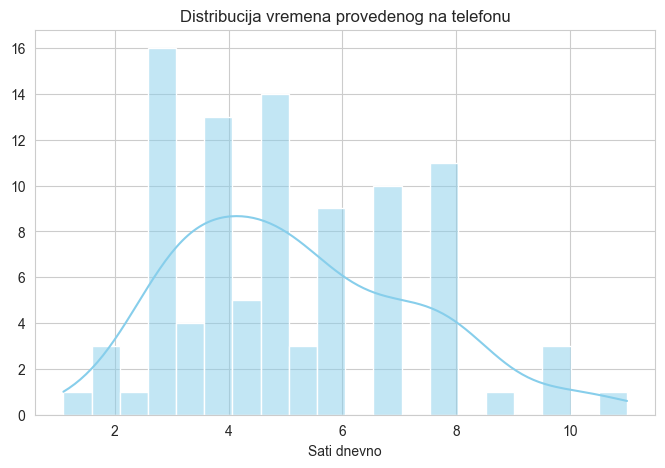

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['Daily_Usage_Hours'], kde=True, bins=20, color='skyblue')
plt.title('Distribucija vremena provedenog na telefonu')
plt.xlabel('Sati dnevno')
plt.ylabel('')
plt.grid(True)
plt.show()

Dok sintetički podaci prate gotovo savršenu i simetričnu krivu, podaci iz ankete pokazuju realnu nepravilnost sa više varijacija i izraženijim ekstremima. Ove razlike potvrđuju da su nam realni podaci neophodni kako bismo razumjeli stvarno, nepredvidivo ponašanje koje je u vještačkim podacima dosta ublaženo.

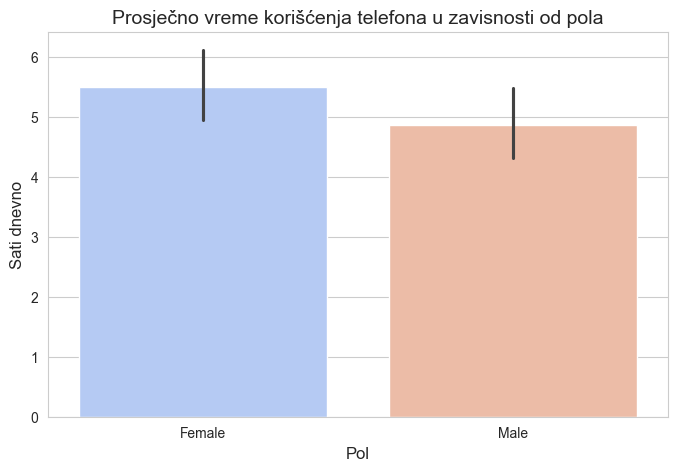

In [24]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Gender', y='Daily_Usage_Hours', palette='coolwarm', hue='Gender', legend=False)
plt.title('Prosječno vreme korišćenja telefona u zavisnosti od pola', fontsize=14)
plt.ylabel('Sati dnevno', fontsize=12)
plt.xlabel('Pol', fontsize=12)
plt.show()

Za razliku od inicijalnog skupa, gdje oba pola imaju slično vijeme provedeno na telefonu, rezultati naše ankete su pokazali da pripadnice ženskog pola blago prednjače.

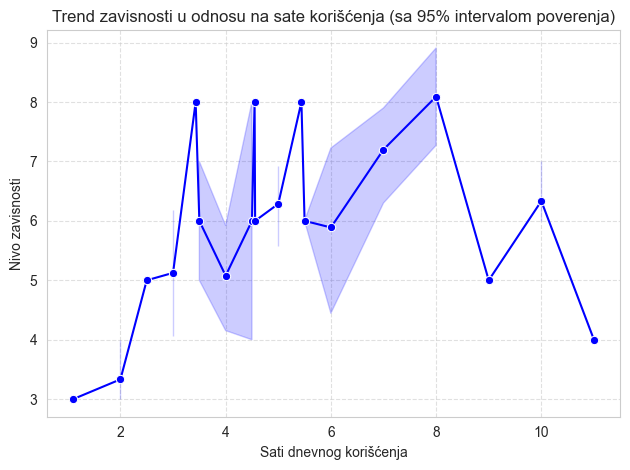

In [25]:
sns.lineplot(data=df, x='Daily_Usage_Hours', y='Addiction_Level', marker='o', color='blue', errorbar=('ci', 95))

plt.title('Trend zavisnosti u odnosu na sate korišćenja (sa 95% intervalom poverenja)')
plt.xlabel('Sati dnevnog korišćenja')
plt.ylabel('Nivo zavisnosti')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Na osnovu grafika vidimo dosta izraženiju varijabilnost, nego što je to slučaj sa sintetičkim podacima. Kod vrijednosti u intervalu 6-10h, sjenka je dosta široka, pa nam to ukazuje da su se ispitanici i pored toliko vremena provedenog na telefonima različito ocjenjivali u pogledu zavisnosti, što može da proističe iz same svrhe za koju koriste telefone (npr. učenje, pa se smatraju manje zavisnim nego što vrijeme provedeno na telefonu govori).

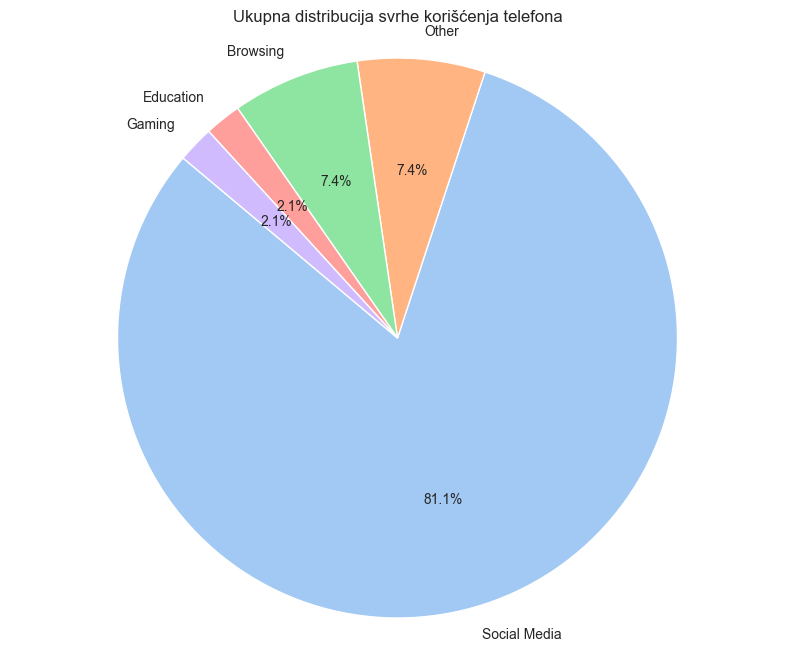

In [26]:
overall_counts = df['Phone_Usage_Purpose'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(overall_counts,
        labels=overall_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=sns.color_palette('pastel'))
plt.title('Ukupna distribucija svrhe korišćenja telefona')
plt.axis('equal')

plt.show()

Vidimo da velika većina telefon koristi najviše za društvene mreže, dok su ostale aktivnosti zanemarljive. Ovo potvrđuje trend koji je danas izrazito pristuan među mlađom populacijom.

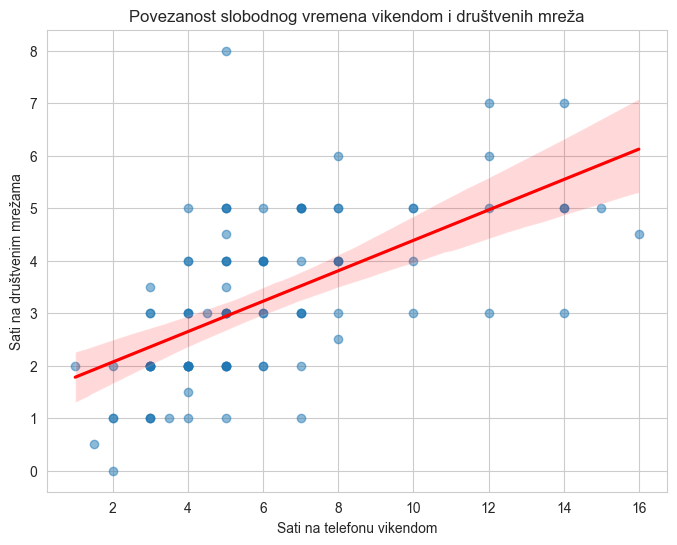

In [27]:
plt.figure(figsize=(8, 6))

sns.regplot(data=df, x='Weekend_Usage_Hours', y='Time_on_Social_Media', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Povezanost slobodnog vremena vikendom i društvenih mreža', fontsize=12)
plt.xlabel('Sati na telefonu vikendom')
plt.ylabel('Sati na društvenim mrežama')
plt.show()

Imamo još jednu potvrdu, da vikednom, kada se još više vremena provodi na telefonu, povećava se i vrijeme provedeno na društvenim mrežama, što nam ukazuje da društvene mreže značajno utiču i na samu pojavu zavisnosti.

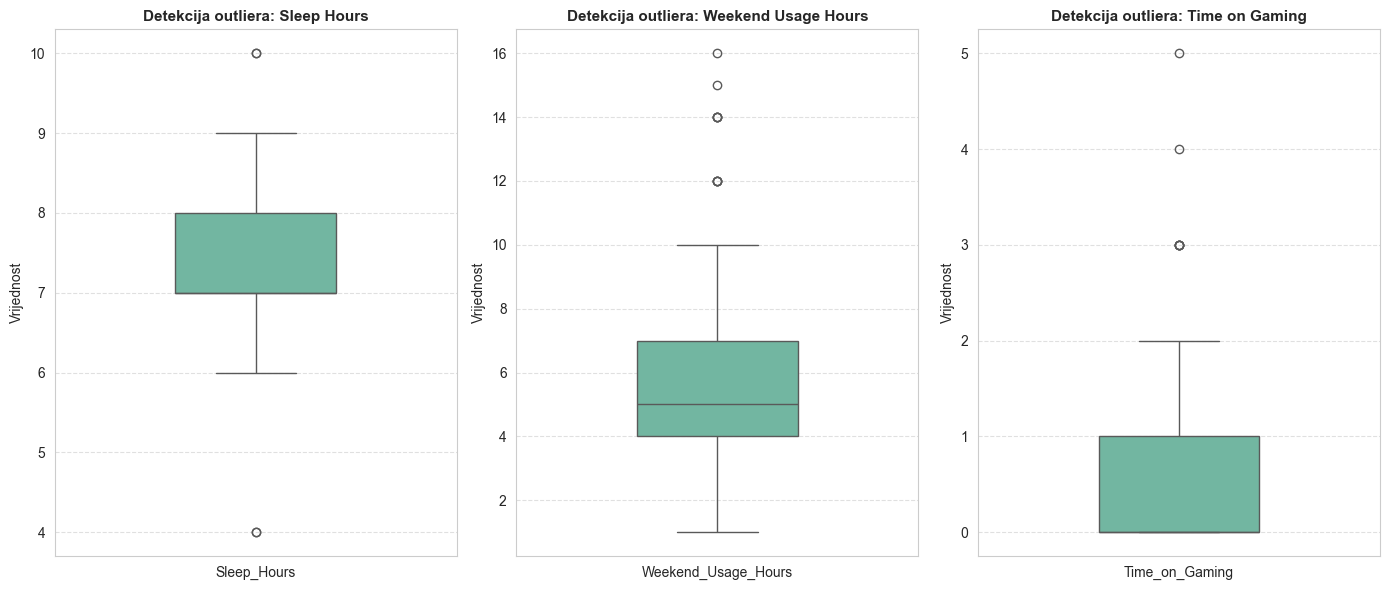

In [28]:
def plot_all_boxplots(df, columns):
    fig, axes = plt.subplots(1, 3, figsize=(14, 6))
    axes = axes.flatten() 

    for i, column_name in enumerate(columns):
        ax = axes[i]
        
        if column_name not in df.columns or not pd.api.types.is_numeric_dtype(df[column_name]):
            ax.set_title(f"Greška: {column_name}")
            continue

        sns.boxplot(y=df[column_name],
                    x=[column_name]*len(df),
                    palette='Set2',
                    width=0.4,
                    hue=[column_name]*len(df),
                    legend=False,
                    ax=ax)

        clean_title = column_name.replace('_', ' ')
        ax.set_title(f'Detekcija outliera: {clean_title}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Vrijednost')
        ax.set_xlabel('')
        ax.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

cols_to_plot = [ 'Sleep_Hours', 'Weekend_Usage_Hours', 'Time_on_Gaming']

plot_all_boxplots(df, cols_to_plot)

Nakon vizuelne analize outlier-a primjećujemo da većina ispitanika spava između 7-8 h dnevno što je i očekivano. S druge strane, posmatrajući vrijeme upotrebe telefona vikendom imamo veći broj ispitanika koji provode više vremena od prosjeka čak i do 18h dnevno. Analizom vremena provedenog igrajući igrice, vidimo da se ta aktivnost ne upražnjava toliko intenzivno na telefonima, što je i očekivano, uzimajući u obzir da se igrice većinski igraju na računarima, međutim imamo nekoliko unosa koji značajno vrijeme posvećuju i toj aktivnosti, što nam ukazuje da i igranje igrica može uzrokovati zavisnost.

Utvrdili smo da prikazani outlieri ne predstavljaju greške pri unosu,  već su posljedica različitih navika ispitanika i treba ih uzeti u obzir.

<h3> Analiza matrice korelacije </h3>

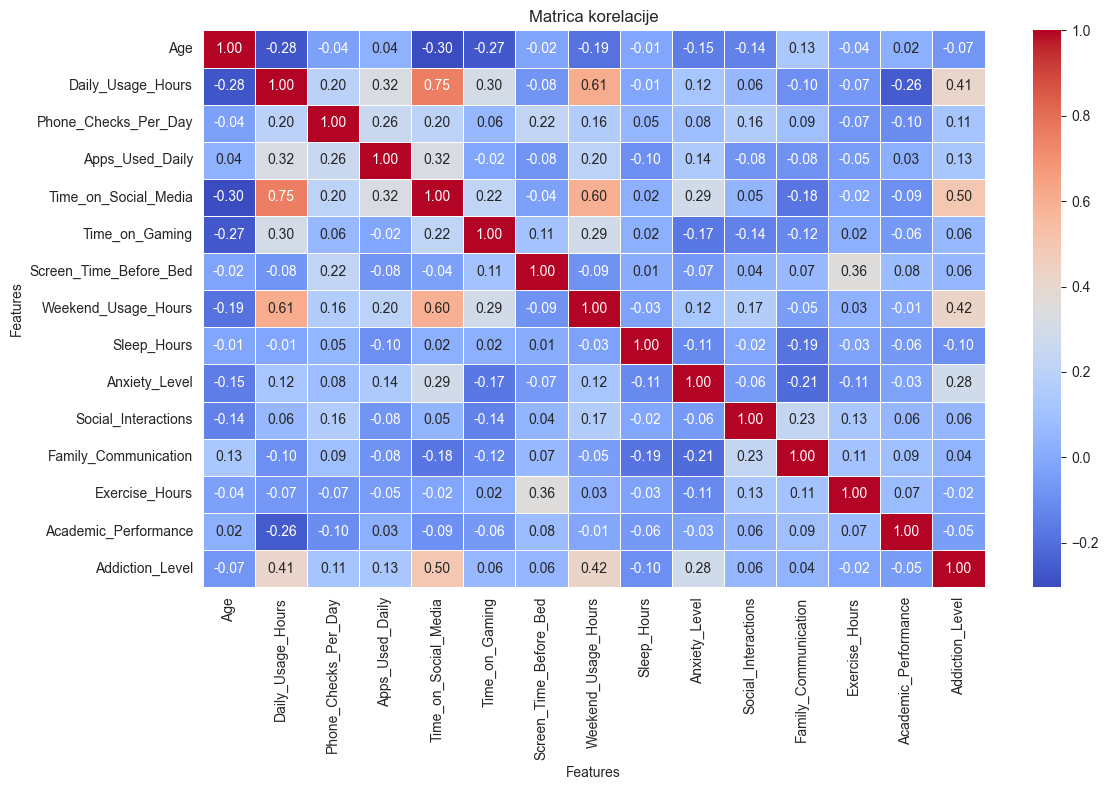

In [29]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Matrica korelacije")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Analizom matrice korelacija vidimo da se ona u velikoj mjeri razlikuje od iste matrice nad sintetičkim skupom podatka. Veliki broj prirodnih i logičnih zavisnosti koje su ostale neprimijećene u sintetičkom skupu, sada su prisutne. Posebno ističemo korelacije između atributa Addiction Level i Weekend Usage Hours (0.42) koja je ranije bila neprimijetna, Academic Performance i Daily Usage Hours (-0.26) koja je takođe bila bliska 0, a sada pokazuje jasnu negativnu korelaciju. Takođe, vidimo i korelacije koje se tiču socioloških aspekata kao što su Family Communication i Social Interactions (0.23), u sintetičkom skupu podataka, ove korelacije su izostavljene.

Sintetički skup podataka je konstruisan sa ciljem da omogući uspješnu predikciju ciljnog obilježja, ali pritom ne modeluje vjerno međuzavisnosti između atributa. Kao posljedica toga, izostaju mnoge realne i logične korelacije koje se javljaju u stvarnim podacima. Ovakav pristup može biti pogodan za treniranje modela, ali nije adekvatan za dublju analizu socioloških i obrazaca ponašanja.